# 💱 원/달러 환율과 코스피·코스닥 지수의 관계 분석

---

## 0️⃣ 주제 정하기

- **분야**: 금융 - 원/달러 환율과 국내 주가지수(코스피·코스닥)의 관계
- **선정 이유**: "환율이 오르면 주가는 어떻게 될까?"는 자주 접하는 경제 이슈지만, 실제로 둘 사이에 어떤 관계가 있고 어느 쪽이 원인이고 결과인지는 명확히 정리된 적이 없어서 데이터로 직접 확인해보고자 함

### 배경지식 - 코스피와 코스닥이란

- **코스피(KOSPI)**: 한국거래소 "유가증권시장"에 상장된 회사들의 주가를 종합한 지수. 삼성전자, SK하이닉스, 현대차 등 규모가 크고 역사가 오래된 **대기업, 특히 수출 중심 기업**이 많이 포함됨 [**환율이 주가에 영향을 주는 경우**]
- **코스닥(KOSDAQ)**: 한국거래소 "코스닥시장"에 상장된 회사들의 주가를 종합한 지수. 코스피보다 상장 문턱이 낮아 **중소기업·벤처·기술주 등 국내 중심 기업**이 많이 포함됨 [**주가가 환율에 영향을 주는 경우**]

### 배경지식 - 환율과 주가의 관계에 대한 두 가지 이론

- **① 전통적 접근(Flow-oriented)**: 환율 상승(원화 약세) → 수출기업이 같은 금액을 달러로 벌어도 원화 환전 시 더 많이 받게 됨 → 기업 이익 증가 기대 → 주가 상승. 수출 중심 경제인 한국에서 설득력 있는 이론 
- **② 포트폴리오 접근(Stock-oriented)**: 국내 증시가 좋아 보임 → 외국인 투자자가 원화를 사서 한국 주식을 매수 → 원화 수요 증가 → 환율 하락(원화 강세). 외국인 자금 유출입이 큰 요즘 금융시장에서 설득력 있는 이론
- 학계에서도 어느 한쪽이 절대적으로 맞다고 정해진 것은 없으며, 시기와 상황에 따라 우세한 방향이 다르다고 봄



## 1️⃣ 분석 질문 정하기

- **메인 질문**: 원/달러 환율과 코스피·코스닥 지수는 어떤 관계가 있으며, 그 관계의 방향(무엇이 원인이고 결과인지)을 외국인 순매수 데이터로 가늠해볼 수 있는가?
- **세부 질문**
  - Q1. 원/달러 환율과 코스피 지수는 상관관계가 있는가?
  - Q2. 원/달러 환율과 코스닥 지수는 상관관계가 있는가?
  - Q3. 외국인 순매수(유가증권시장·코스닥시장)와 각 지수(코스피·코스닥)는 관계가 있는가?
  - Q4. 외국인 순매수(유가증권시장·코스닥시장)와 환율은 관계가 있는가?
- **필요 컬럼**: 날짜, 원/달러 환율, 코스피 지수, 코스피 외국인 순매수, 코스닥 지수, 코스닥 외국인 순매수



## 2️⃣ 수집 대상 선정

- **출처**: 한국은행 경제통계시스템(ECOS)
- **URL**: `https://ecos.bok.or.kr/#/SearchStat` (통계표: 3.1.1. 환율, 1.5.1.1. 주식시장(일))
- **수집 항목**: 원/달러 종가, KOSPI지수, 외국인 순매수(유가증권시장), KOSDAQ지수, 외국인 순매수(코스닥시장)
- **윤리·법 확인**
  - robots.txt 확인 결과 `Disallow:` (전체 허용)으로 스크래핑에 문제없음을 확인
  - 로그인 불필요, 개인정보 미포함
  - 공식 국가통계기관의 공개 통계자료로 안전성·신뢰성 확보



## 3️⃣ 데이터 수집 및 저장

- ECOS는 조회 조건에 따라 화면이 자바스크립트로 렌더링되는 동적 페이지로, `requests`만으로는 데이터를 가져올 수 없어 **Selenium**으로 페이지를 로딩한 뒤 `BeautifulSoup`으로 파싱
- 데이터 그리드가 `<table>`이 아닌 `<td class="rg-data-cell">` 구조로 되어 있어, 행(`<tr>`) 단위로 접근해 날짜 행과 값 행을 직접 짝지어 추출
- 환율(245일치)과 코스피·코스닥·외국인 순매수(245일치)를 각각 별도로 수집
- CSV 저장: `exchange_rate.csv`, `market_extra.csv`



## 4️⃣ 데이터 정제

- **병합**: 환율 데이터와 지수·순매수 데이터를 날짜 기준으로 병합 (245행)
- **날짜 타입 변환**: 문자열(`"2025/07/24"`) → `datetime64` 변환
- **숫자 타입 변환**: 콤마 포함 문자열(`"1,367.20"`) → `float` 변환
- **결측치 처리**: 병합 후 1개 행(2025년 12월 31일)에서 전 항목 결측 발견. 이는 연말 결산으로 인한 국내 증시·외환시장 휴장일이라 값이 존재하지 않는 것이 정상이므로 해당 행 제거 (245 → 244행)

### 최종 데이터(`final_all`) 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `날짜` | 거래일 (datetime) |
| `원달러_종가` | 원/달러 환율 종가(15:30 기준) |
| `코스피지수` | KOSPI 종합주가지수 (1980.01.04=100 기준) |
| `코스피외국인순매수` | 유가증권시장 외국인 순매수 금액(억원) — 매수액에서 매도액을 뺀 값 |
| `코스닥지수` | KOSDAQ 종합주가지수 (1996.07.01=1000 기준) |
| `코스닥외국인순매수` | 코스닥시장 외국인 순매수 금액(억원) |



## 5️⃣ 시각화로 살펴보기

### 코스피 관련 (Q1, Q3-1, Q4-1)
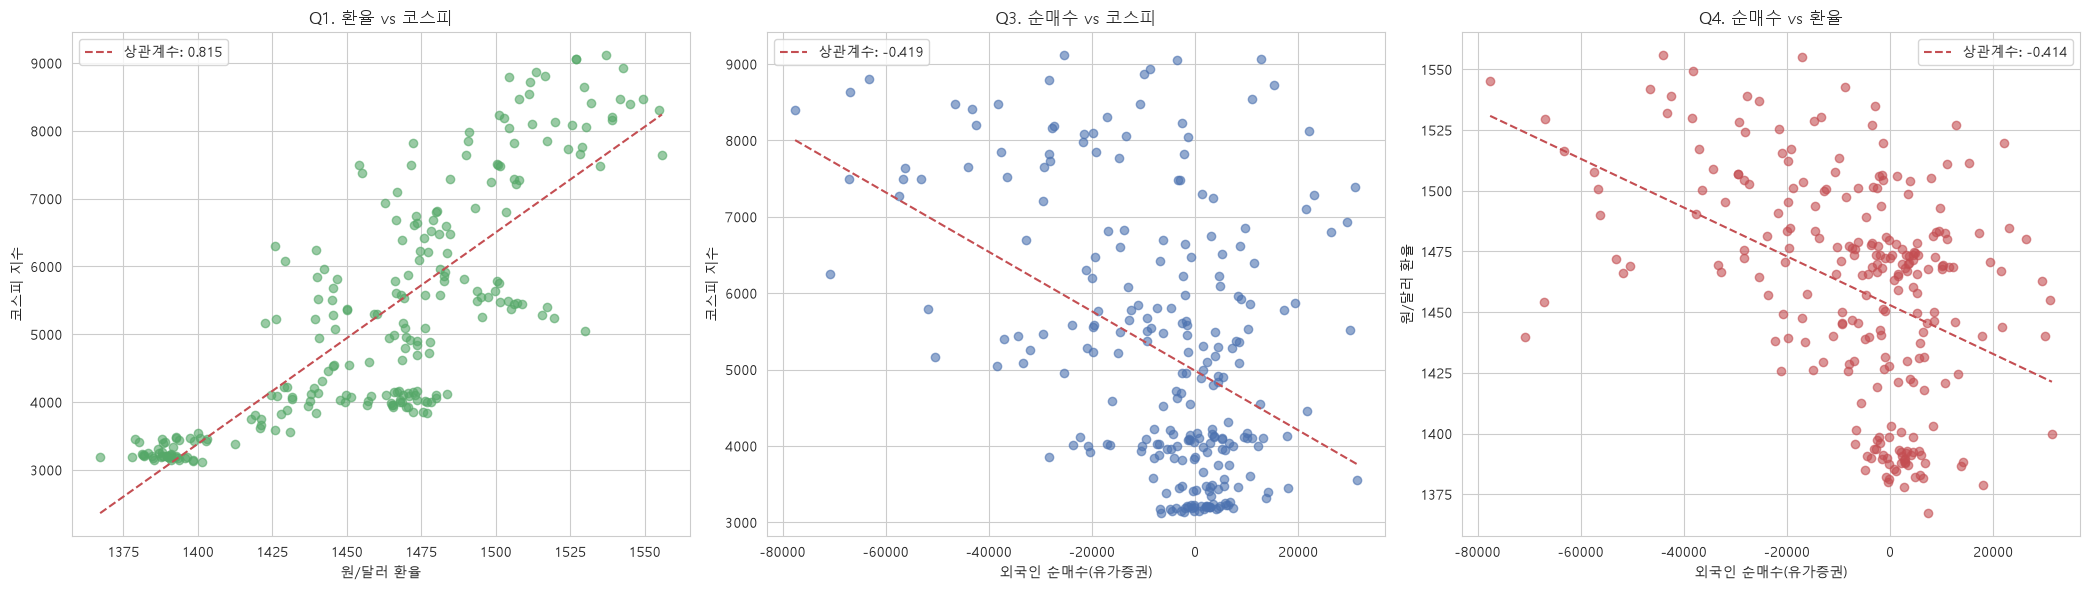

- **Q1. 환율 vs 코스피**: 상관계수 **0.815**로 매우 강한 양의 상관관계. 지난 1년간 환율이 오를 때 코스피도 거의 같은 방향으로 크게 상승함

---

- **Q3-1. 외국인 순매수(유가증권) vs 코스피 지수**: 상관계수 **-0.419**로 예상과 다른 음의 상관관계. 참고로 외국인 순매수와 코스피는 양의 상관관계가 나와야 이론 ②와 연결됨. ("외국인이 국내 주식을 많이 살 때 = 외국인 순매수가 늘어날 때" 코스피도 함께 올라야 자연스럽기 때문)

---

- **Q4-1. 외국인 순매수(유가증권) vs 환율**: 상관계수 **-0.414**로 음의 상관관계. 외국인 순매수가 늘어날수록 환율이 낮아지는(원화 강세) 경향으로, "외국인 자금 유입 → 원화 수요 증가 → 환율 하락"이라는 ②번 이론과 방향이 일치함



### 코스닥 관련 (Q2, Q3-2, Q4-2)
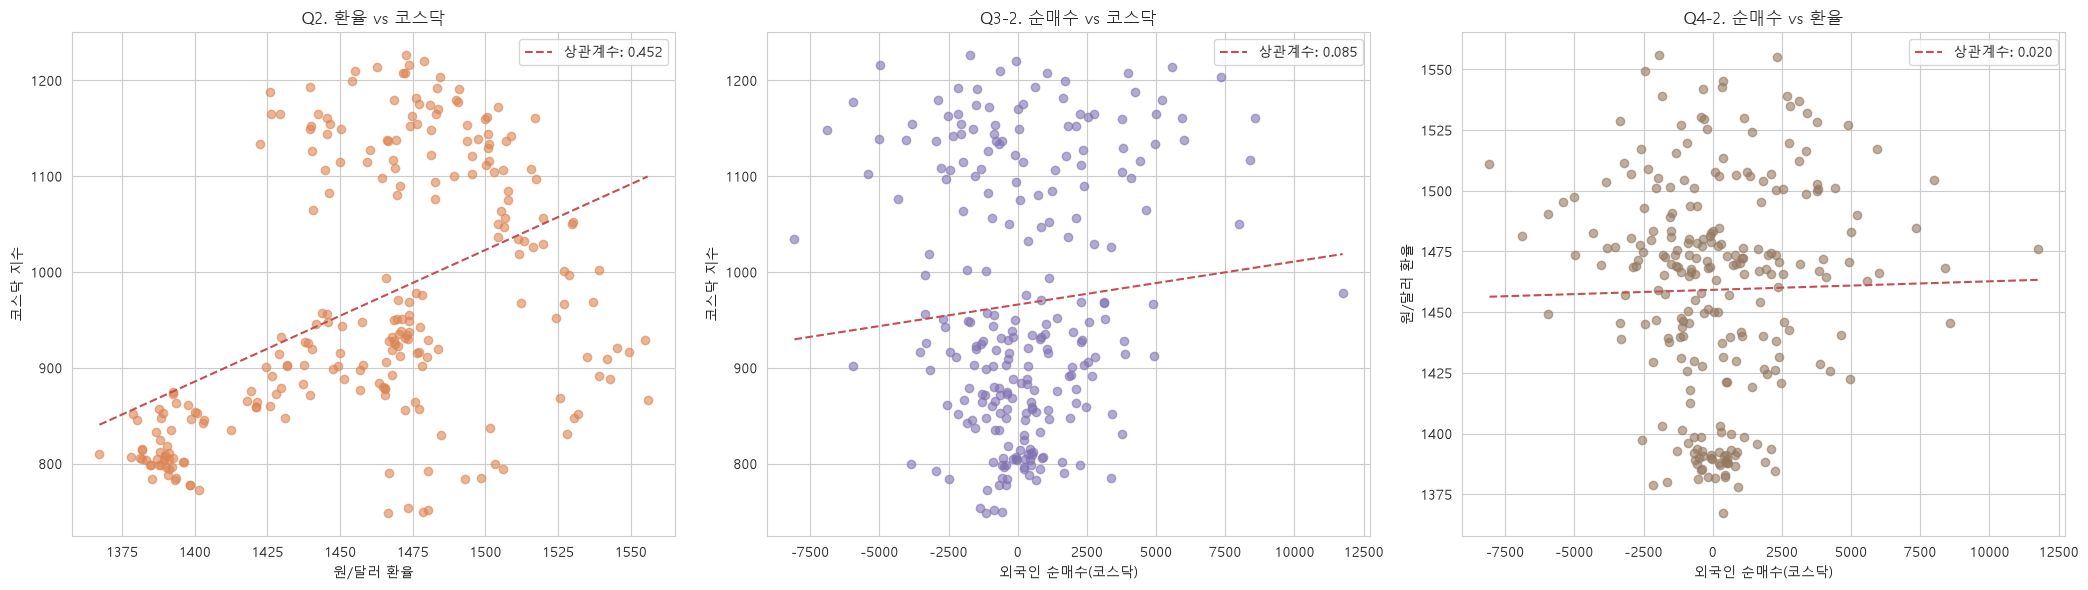
- **Q2. 환율 vs 코스닥**: 상관계수 **0.452**로 중간 정도의 양의 상관관계. 코스피(0.815)에 비해 뚜렷하게 약함

---

- **Q3-2. 외국인 순매수(코스닥) vs 코스닥 지수**: 상관계수 **0.085**로 사실상 관계없음

---

- **Q4-2. 외국인 순매수(코스닥) vs 환율**: 상관계수 **0.020**로 사실상 관계없음



## 6️⃣ 마무리 정리

- **처음 질문**: 원/달러 환율과 코스피·코스닥 지수는 어떤 관계가 있으며, 그 방향을 외국인 순매수로 가늠할 수 있는가?
- **알게 된 점**
  - 코스피는 환율과 매우 강한 상관관계(0.815)를 보였으나, 코스닥은 상대적으로 약한 상관관계(0.452)를 보였다. 코스피는 수출 중심 대기업이 많고 코스닥은 국내 중심 중소·벤처기업이 많다는 점을 고려하면, 이는 "환율이 수출기업 실적에 영향을 준다"는 ①번 이론과 부합하는 결과로 해석할 수 있다.
  - 외국인 순매수는 코스피와 -0.419, 환율과 -0.414의 음의 상관관계를 보인 반면, 코스닥과는 거의 무관했다(0.085, 0.020). 코스피에서 외국인 순매수-환율 관계는 ②번 이론과 방향이 일치했지만, 외국인 순매수-코스피 관계는 오히려 반대(음수)로 나와 ②번 이론이 완전히 성립한다고 보기는 어렵다.
  - 종합하면, 이번 강세장에서 코스피와 환율이 같이 오른 게 꼭 외국인 자금 유입 때문이라고 단정할 수는 없다. 다만 코스닥이 코스피보다 환율과의 상관관계가 낮게 나온 걸 보면, 내수기업이 많은 코스닥은 환율 영향을 덜 받고 수출기업이 많은 코스피는 환율 영향을 더 받는다고 볼 수 있어, "수출기업이 많은 시장일수록 환율에 더 민감하다"는 ①번 이론과 같은 방향(수출기업이 많이 포함된 시장일수록 이 효과(환율↑ → 주가↑)가 더 강하게, 더 자주 나타날 것)의 결과로 보인다. 다만 이것만으로 이론이 맞다고 확정할 순 없고, 실제로 두 시장의 수출/내수 기업 비중을 확인해봐야 한다.
- **한계**
  - 절대 가격(환율 수준, 지수 수준) 기준으로 상관관계를 계산해, 두 지표가 각자 다른 이유로 함께 우상향하는 "허위 상관관계(spurious correlation: 두 데이터가 서로 아무 인과관계가 없어도, 둘 다 시간이 지나면서 그냥 꾸준히 우상향하는 추세를 가진다면 상관계수가 높게 나올 수 있음.)" 가능성을 배제하지 못했다. 전일 대비 변화율(수익률) 기준으로 재분석하면 더 엄밀한 관계를 확인할 수 있을 것이다.
  - 상관관계 분석만으로는 인과관계의 방향(무엇이 원인이고 결과인지)을 확정할 수 없다.
  - 환율과 지수 변화 사이의 시차(예: 오늘 환율 변화가 며칠 뒤 지수에 반영되는지)를 고려하지 않았다.
- **후속 질문**
  - 절대 가격 대신 일별 변화율(%)로 재계산하면 상관관계가 어떻게 달라지는지
  - 환율 변화와 지수 변화 사이에 1~5일 정도의 시차(lag)를 두고 분석하면 더 뚜렷한 선후관계를 확인할 수 있는지
  - 외국인 순매수 외에 개인·기관 투자자별 순매수 데이터를 추가하면, 이번 강세장의 실제 주도 세력을 더 명확히 파악할 수 있을 것이다